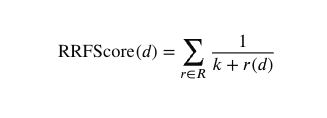

In [ ]:
bm_25 = ["c1","c3","c2","c6"]
cosine = ["c2", "c1","c8","c3"]

from collections import defaultdict

def rrf_calculate(result_lists, k=4):
  scores = defaultdict(float)

  for list_index,results in enumerate(result_lists,start=1):
    print(f"Processing result list {results}")

    for rank, doc_id in enumerate(results,start=1):
      contribution = 1/(k+rank)
      scores[doc_id] += contribution
      print(f"doc_id = {doc_id} , rank = {rank}, contribution: {contribution}, total score: {scores[doc_id]}")

  final_results = sorted(scores.items(), key=lambda x: x[1], reverse=True)
  print(f"final results: {final_results}")
  return final_results

rrf_calculate([bm_25, cosine])

Processing result list ['c1', 'c3', 'c2', 'c6']
doc_id = c1 , rank = 1, contribution: 0.2, total score: 0.2
doc_id = c3 , rank = 2, contribution: 0.16666666666666666, total score: 0.16666666666666666
doc_id = c2 , rank = 3, contribution: 0.14285714285714285, total score: 0.14285714285714285
doc_id = c6 , rank = 4, contribution: 0.125, total score: 0.125
Processing result list ['c2', 'c1', 'c8', 'c3']
doc_id = c2 , rank = 1, contribution: 0.2, total score: 0.34285714285714286
doc_id = c1 , rank = 2, contribution: 0.16666666666666666, total score: 0.3666666666666667
doc_id = c8 , rank = 3, contribution: 0.14285714285714285, total score: 0.14285714285714285
doc_id = c3 , rank = 4, contribution: 0.125, total score: 0.29166666666666663
final results: [('c1', 0.3666666666666667), ('c2', 0.34285714285714286), ('c3', 0.29166666666666663), ('c8', 0.14285714285714285), ('c6', 0.125)]


[('c1', 0.3666666666666667),
 ('c2', 0.34285714285714286),
 ('c3', 0.29166666666666663),
 ('c8', 0.14285714285714285),
 ('c6', 0.125)]

# Reranker Demo

In [ ]:
from sentence_transformers import CrossEncoder

model = CrossEncoder("Qwen/Qwen3-Reranker-0.6B")

query = "What is the capital of China?"
documents = [
    "The capital of China is Beijing.",
    "Gravity is a force that attracts two bodies towards each other. It gives weight to physical objects and is responsible for the movement of planets around the sun.",
]

pairs = [(query, doc) for doc in documents]
scores = model.predict(pairs)
print(scores)
# [ 7.625 -11.375]

rankings = model.rank(query, documents)
print(rankings)
# [{'corpus_id': 0, 'score': 7.625}, {'corpus_id': 1, 'score': -11.375}]


modules.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/14.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/741 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

[  7.75   -12.0625]
[{'corpus_id': 0, 'score': np.float32(7.75)}, {'corpus_id': 1, 'score': np.float32(-12.0625)}]


# Chunk Comparision

In [ ]:
# Create chunk hash
import hashlib

def normalize_text(text: str) -> str:
    return " ".join(text.strip().lower().split())

def make_hash(text: str) -> str:
    return hashlib.sha256(normalize_text(text).encode("utf-8")).hexdigest()

def compare_chunks(old_registry, new_registry):
    new_chunks = []
    changed_chunks = []
    unchanged_chunks = []
    deleted_chunks = []

    old_keys = set(old_registry.keys())
    new_keys = set(new_registry.keys())

    for key in new_keys:
        new_text = new_registry[key]
        new_hash = make_hash(new_text)

        if key not in old_registry:
            new_chunks.append((key, new_hash))
        else:
            old_hash = old_registry[key]["hash"]
            if old_hash == new_hash:
                unchanged_chunks.append((key, new_hash))
            else:
                changed_chunks.append((key, old_hash, new_hash))

    for key in old_keys - new_keys:
        deleted_chunks.append(key)

    return {
        "new": new_chunks,
        "changed": changed_chunks,
        "unchanged": unchanged_chunks,
        "deleted": deleted_chunks,
    }


old_registry = {
    "BERT.pdf::page_4::chunk_0": {
        "text": "BERT is a bidirectional transformer model.",
        "hash": make_hash("BERT is a bidirectional transformer model."),
        "vector_id": "vec_100"
    },
    "BERT.pdf::page_4::chunk_1": {
        "text": "It is pre-trained using masked language modeling.",
        "hash": make_hash("It is pre-trained using masked language modeling."),
        "vector_id": "vec_101"
    }
}

new_registry = {
    "BERT.pdf::page_4::chunk_0": "BERT is a bidirectional transformer model.",
    "BERT.pdf::page_4::chunk_1": "It is pre-trained using masked language modeling and NSP.",
    "BERT.pdf::page_4::chunk_2": "BERT achieved strong results on NLP benchmarks."
}

result = compare_chunks(old_registry, new_registry)

print("NEW:")
for item in result["new"]:
    print(item)

print("\nCHANGED:")
for item in result["changed"]:
    print(item)

print("\nUNCHANGED:")
for item in result["unchanged"]:
    print(item)

print("\nDELETED:")
for item in result["deleted"]:
    print(item)

NEW:
('BERT.pdf::page_4::chunk_2', '7dc4eae371d43596e47c2c8b6a7695782a644e29d8b2c9288698ed674bc0d1dc')

CHANGED:
('BERT.pdf::page_4::chunk_1', '8ead0a82c00785ca30834761218bd53260ca767d97a367b6d5808583a38d7db3', 'e604be54682d855a45f3e17709a6e1ed7519661e5b42b610cf83cb9013175b58')

UNCHANGED:
('BERT.pdf::page_4::chunk_0', 'bf207bef69cd103682f2a8b5a53c654d18000f4b3e15dde85d8ae0c2c4aa4d89')

DELETED:
